In [1]:
import pandas as pd
import numpy as np
import os
from matplotlib.pyplot import *


rcParams['mathtext.rm'] = "Arial"
rcParams['font.family'] = 'Arial'

In [2]:
import numpy as np
def get_mean_std(performance_list):
    perf_array = np.array(performance_list)  # 将列表转换为numpy数组
    mean_value = perf_array.mean(axis=0)     # 计算均值（对多次运行的结果）
    std_value = perf_array.std(axis=0)       # 计算标准差
    return mean_value, std_value

In [12]:
from data_split import process_folder
from train_evaluation import normalize_data, train_LSmodels, train_RFmodels
#初始化
all_LSperformance1_mean = []
all_LSperformance1_std = []
all_LSperformance2_mean = []
all_LSperformance2_std = []
all_RFperformance1_mean = []
all_RFperformance1_std = []
all_RFperformance2_mean = []
all_RFperformance2_std = []


In [16]:
batch_dir = "experiment_results/batch2" #计算那一批次就用哪个文件夹

In [17]:
df_stage1, df_stage2 = process_folder(batch_dir, recursive= False) #某一批次的数据（用于模型一，模型二）

X1 = df_stage1.drop(['Y', 'source_file'], axis=1)  # 特征：排除标签和源文件
y1 = df_stage1['Y']
X2 = df_stage2.drop(['Y', 'source_file'], axis=1)
y2 = df_stage2['Y']

#数据归一化
norm_X1 = normalize_data(X1)
norm_X2 = normalize_data(X2)

#收录第一批次的两个模型的性能指标
_, LSperformance1 = train_LSmodels(norm_X1, y1)
_, LSperformance2 = train_LSmodels(norm_X2, y2)
_, RFperformance1,_ = train_RFmodels(norm_X1, y1)
_, RFperformance2,_ = train_RFmodels(norm_X2, y2)

处理文件: (Gd1-3 Co0.5-1 Na1-2 OH2-4).csv
 样本数: 100，有晶体: 30，Gd42: 15
处理文件: (Gd1-3 Co1-2 Na0.5-1 OH2-4).csv
 样本数: 100，有晶体: 50，Gd42: 43
处理文件: GdCoOAc_(OH3-4).csv
 样本数: 100，有晶体: 11，Gd42: 0

文件夹处理完成！
共处理 3 个文件
合并后总样本数: 300
总有晶体样本: 91 (30.3%)
总Gd42晶体: 58 (63.7%)
Training LabelSpreading with random_state=42
Training LabelSpreading with random_state=43
Training LabelSpreading with random_state=44
Training LabelSpreading with random_state=45
Training LabelSpreading with random_state=46
Training LabelSpreading with random_state=47
Training LabelSpreading with random_state=48
Training LabelSpreading with random_state=49
Training LabelSpreading with random_state=50
Training LabelSpreading with random_state=51
Training LabelSpreading with random_state=52
Training LabelSpreading with random_state=53
Training LabelSpreading with random_state=54
Training LabelSpreading with random_state=55
Training LabelSpreading with random_state=56
Training LabelSpreading with random_state=57
最佳模型验证集准确率: 0.9167
Trainin

In [ ]:
#计算并保存数据
LSmean1, LSstd1 = get_mean_std(LSperformance1)
LSmean2, LSstd2 = get_mean_std(LSperformance2)
RFmean1, RFstd1 = get_mean_std(RFperformance1)
RFmean2, RFstd2 = get_mean_std(RFperformance2)
all_LSperformance1_mean.append(LSmean1)
all_LSperformance1_std.append(LSstd1)
all_LSperformance2_mean.append(LSmean2)
all_LSperformance2_std.append(LSstd2)
all_RFperformance1_mean.append(RFmean1)
all_RFperformance1_std.append(RFstd1)
all_RFperformance2_mean.append(RFmean2)
all_RFperformance2_std.append(RFstd2)

[array([0.678125  , 0.63777538, 0.49096969, 0.73428714]), array([0.81041667, 0.757088  , 0.65801037, 0.87370356])]
[array([0.07008644, 0.07277603, 0.13645307, 0.05934084]), array([0.04559598, 0.06246937, 0.09279368, 0.04949313])]


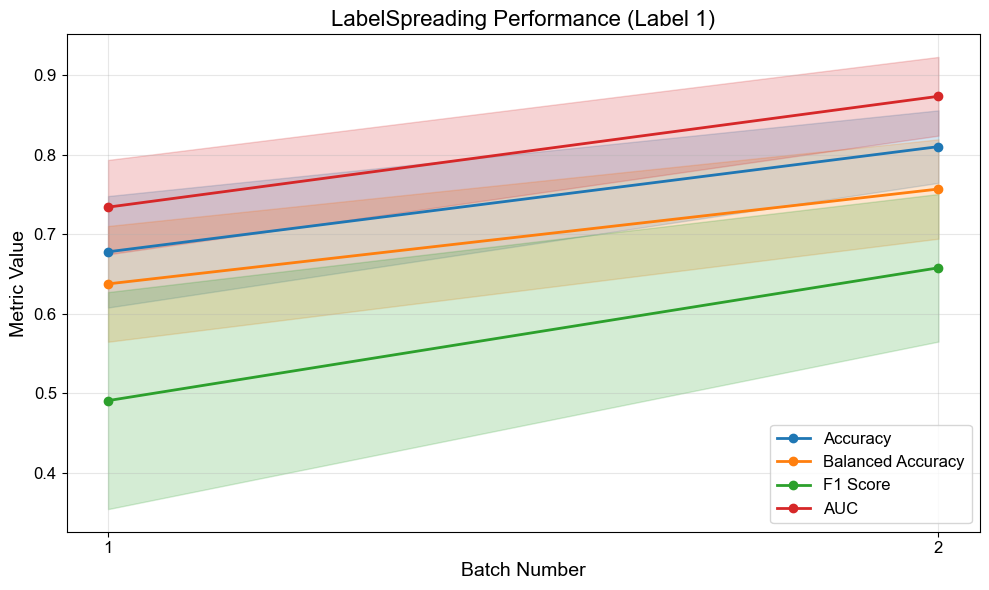

In [19]:
from plot_tools import plot_batch_performance
import pandas as pd
print(all_LSperformance1_mean)
print(all_LSperformance1_std)
# 绘制图表
plot_batch_performance(
    all_LSperformance1_mean,  # 核心输入：批次×指标的均值（二维数组/列表）
    all_LSperformance1_std,   # 核心输入：批次×指标的标准差（同结构）
    title="LabelSpreading Performance (Label 1)",    # 图标题
)

[array([0.67083333, 0.66794959, 0.56707251, 0.70565762]), array([0.69736842, 0.67293072, 0.76399312, 0.72978671])]
[array([0.09851325, 0.1021209 , 0.14071682, 0.13589814]), array([0.09933993, 0.08646672, 0.09278782, 0.09644288])]


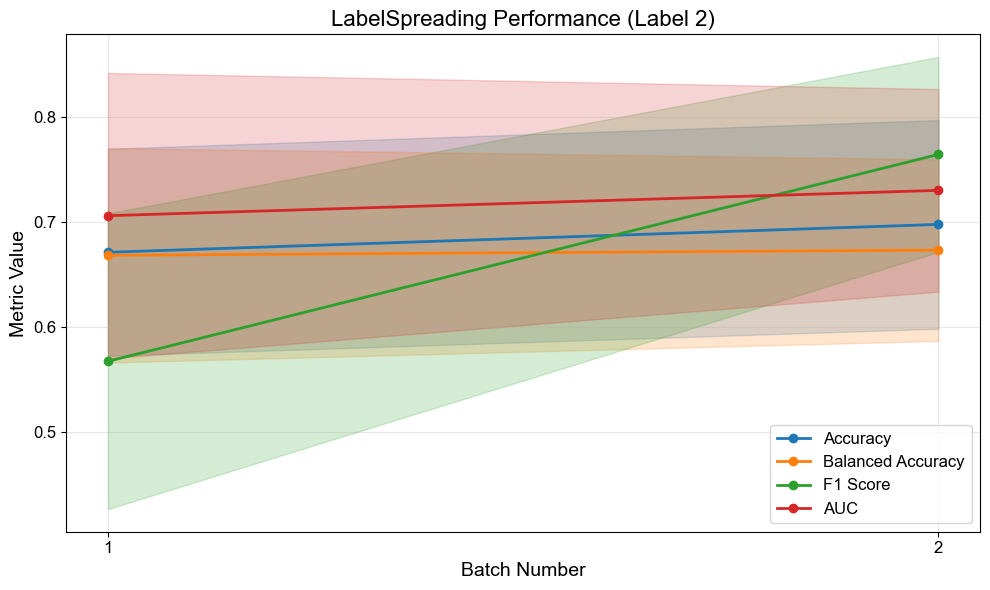

In [20]:
print(all_LSperformance2_mean)
print(all_LSperformance2_std)
# 绘制图表
plot_batch_performance(
    all_LSperformance2_mean,  # 核心输入：批次×指标的均值（二维数组/列表）
    all_LSperformance2_std,   # 核心输入：批次×指标的标准差（同结构）
    title="LabelSpreading Performance (Label 2)",    # 图标题
)

[array([0.6890625, 0.6607898, 0.5348683, 0.7484693]), array([0.79270833, 0.7478667 , 0.64584535, 0.85800727])]
[array([0.06432872, 0.06366843, 0.09878102, 0.06026843]), array([0.04328874, 0.04725686, 0.07654534, 0.03909838])]


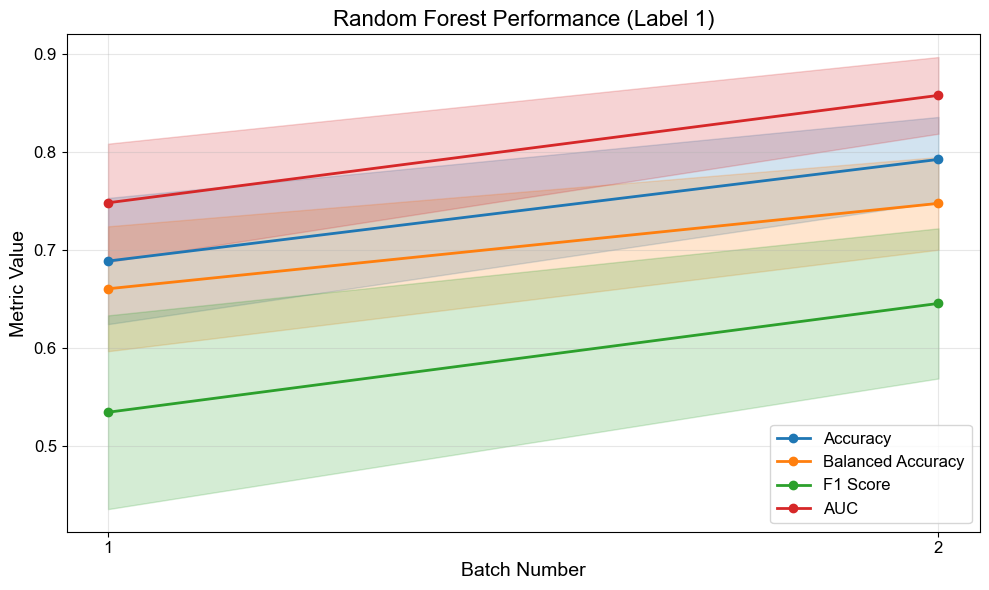

In [21]:
print(all_RFperformance1_mean)
print(all_RFperformance1_std)
# 绘制图表
plot_batch_performance(
    all_RFperformance1_mean,  # 核心输入：批次×指标的均值（二维数组/列表）
    all_RFperformance1_std,   # 核心输入：批次×指标的标准差（同结构）
    title="Random Forest Performance (Label 1)",    # 图标题
)

[]
[]


d:\workspace\Phase_diagram\GdCoAc_phase_diagram-main\plot_tools.py:163: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=fontsize-2)


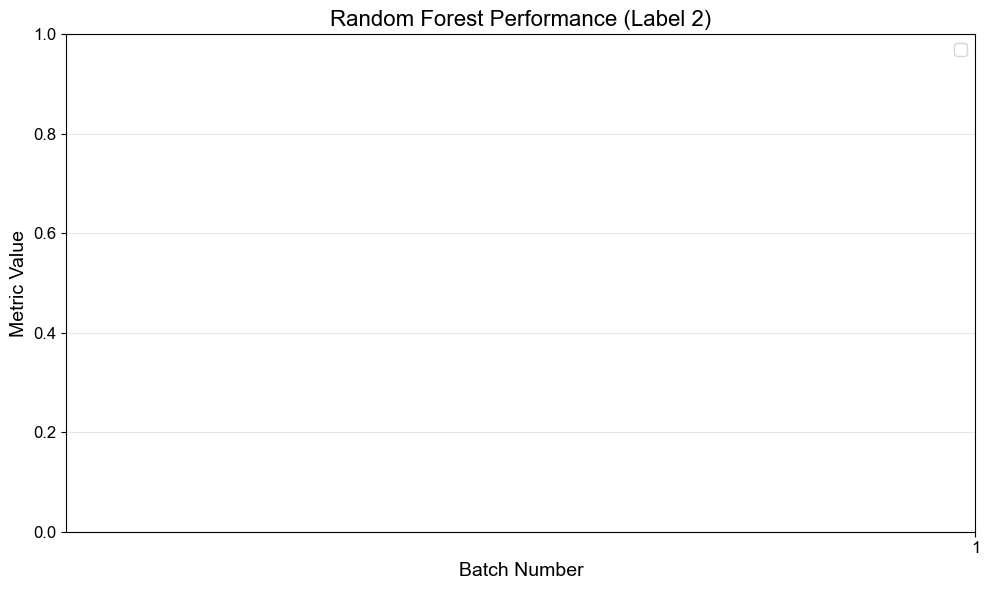

In [22]:
print(all_RFperformance2_mean)
print(all_RFperformance2_std)
# 绘制图表
plot_batch_performance(
    all_RFperformance2_mean,  # 核心输入：批次×指标的均值（二维数组/列表）
    all_RFperformance2_std,   # 核心输入：批次×指标的标准差（同结构）
    title="Random Forest Performance (Label 2)",    # 图标题
)